In [45]:
# Import required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
# Import custom data processing and visualization functions
# from the src/ folder
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.data_processing import (
    convert_timestamp,
    create_time_features,
    map_weekdays,
    extract_reason
)

from src.visualization import (
    plot_reason_distribution
)

In [47]:
# Load the 911 calls dataset
df = pd.read_csv('../data/raw/911.csv')

In [ ]:
# Display first 5 rows of the dataset
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In [49]:
# Display dataset information such as:
# - number of rows and columns
# - data types
# - missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  str    
 3   zip        86637 non-null  float64
 4   title      99492 non-null  str    
 5   timeStamp  99492 non-null  str    
 6   twp        99449 non-null  str    
 7   addr       98973 non-null  str    
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), str(5)
memory usage: 6.8 MB


In [ ]:
# statistical summary of numerical columns
df.describe()

,lat,lng,zip,e
count,99492.000000,99492.000000,86637.000000,99492.0
mean,40.159526,-75.317464,19237.658298,1.0
std,0.094446,0.174826,345.344914,0.0
min,30.333596,-95.595595,17752.000000,1.0
25%,40.100423,-75.392104,19038.000000,1.0
50%,40.145223,-75.304667,19401.000000,1.0
75%,40.229008,-75.212513,19446.000000,1.0
max,41.167156,-74.995041,77316.000000,1.0


In [51]:
# Display all column names in the dataset
df.columns

Index(['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'e'], dtype='str')

# Feature Engineering

Creating useful time-based features from the timestamp column.

In [ ]:
# Convert timestamp column into datetime format
df = convert_timestamp(df)

# Create new time-based features:
# - Hour
# - Month
# - Day of Week
df = create_time_features(df)

# Convert weekday numbers into weekday names
# Example:
# 0 -> Mon
# 1 -> Tue
df = map_weekdays(df)

# Extract emergency category from title column
# Example:
# "EMS: BACK PAINS" -> "EMS"
df = extract_reason(df)

In [53]:
# Display modified features to verify correctness
df[['timeStamp', 'Hour', 'Month', 'Day of Week', 'Reason']].head()

,timeStamp,Hour,Month,Day of Week,Reason
0,2015-12-10 17:40:00,17,12,Thu,EMS
1,2015-12-10 17:40:00,17,12,Thu,EMS
2,2015-12-10 17:40:00,17,12,Thu,Fire
3,2015-12-10 17:40:01,17,12,Thu,EMS
4,2015-12-10 17:40:01,17,12,Thu,EMS


# Emergency Call Distribution

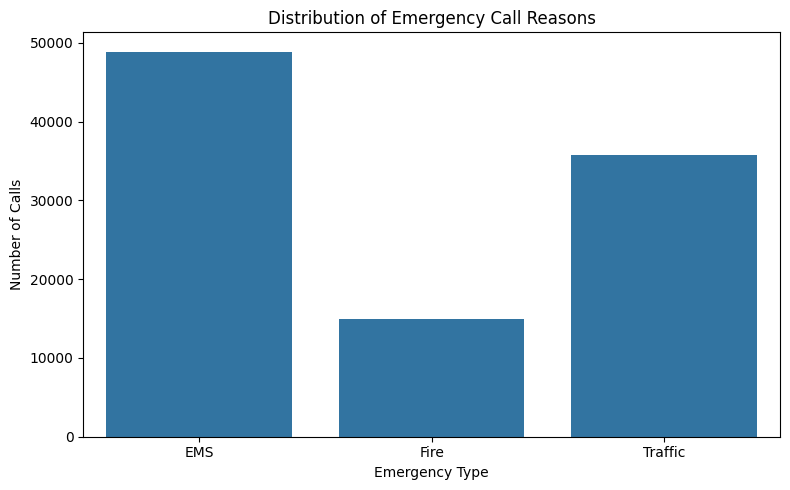

In [54]:
# Visualize distribution of emergency call reasons
plot_reason_distribution(df)

# Monthly Call Trends

In [55]:
# Group dataset by Month and count number of records
byMonth = df.groupby('Month').count()

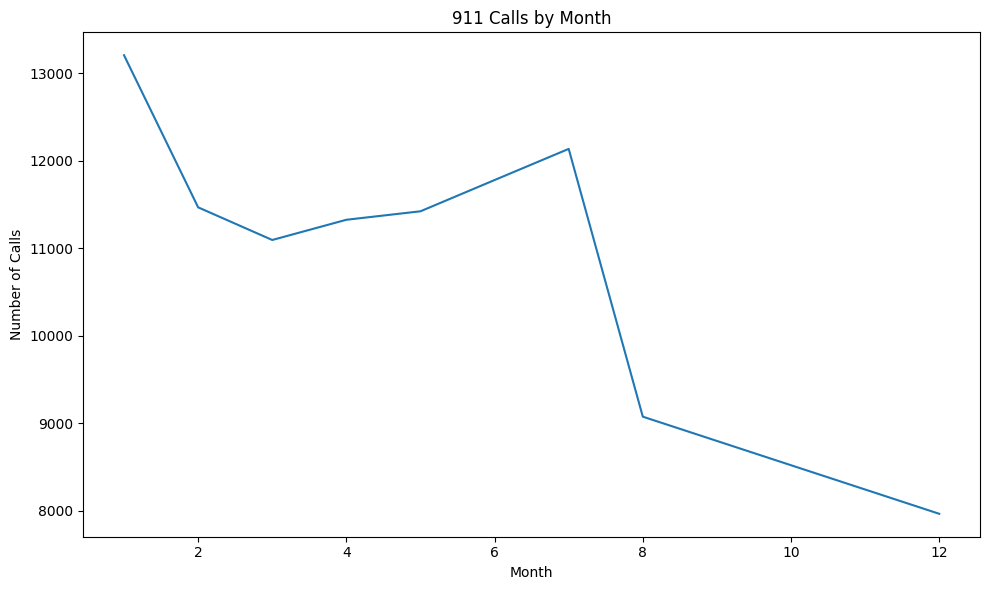

In [56]:
# Plot monthly 911 call trends
plt.figure(figsize=(10,6))

byMonth['twp'].plot()

plt.title('911 Calls by Month')

plt.xlabel('Month')

plt.ylabel('Number of Calls')

plt.tight_layout()

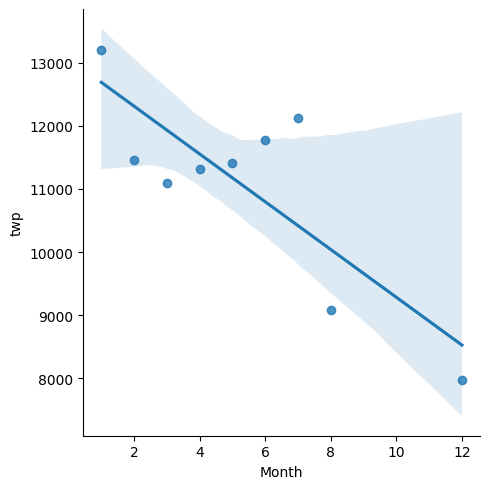

In [57]:
# Create regression plot to analyze monthly trend pattern
sns.lmplot(
    x='Month',
    y='twp',
    data=byMonth.reset_index()
)

# Daily Time Series Analysis

In [58]:
# Extract only the date from timestamp column
df['Date'] = df['timeStamp'].apply(lambda t: t.date())

In [59]:
# Group dataset by Date
byDate = df.groupby('Date').count()

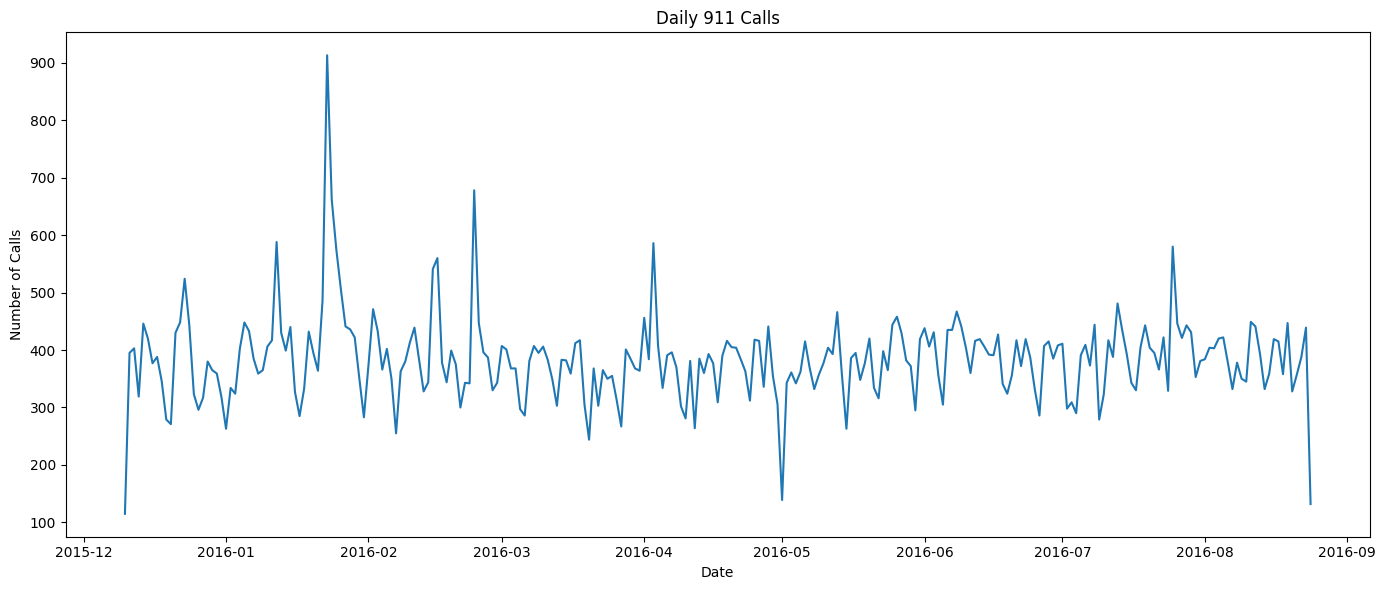

In [60]:
# Plot daily 911 call time series
plt.figure(figsize=(14,6))

byDate['twp'].plot()

plt.title('Daily 911 Calls')

plt.xlabel('Date')

plt.ylabel('Number of Calls')

plt.tight_layout()

# Emergency Category Time Series

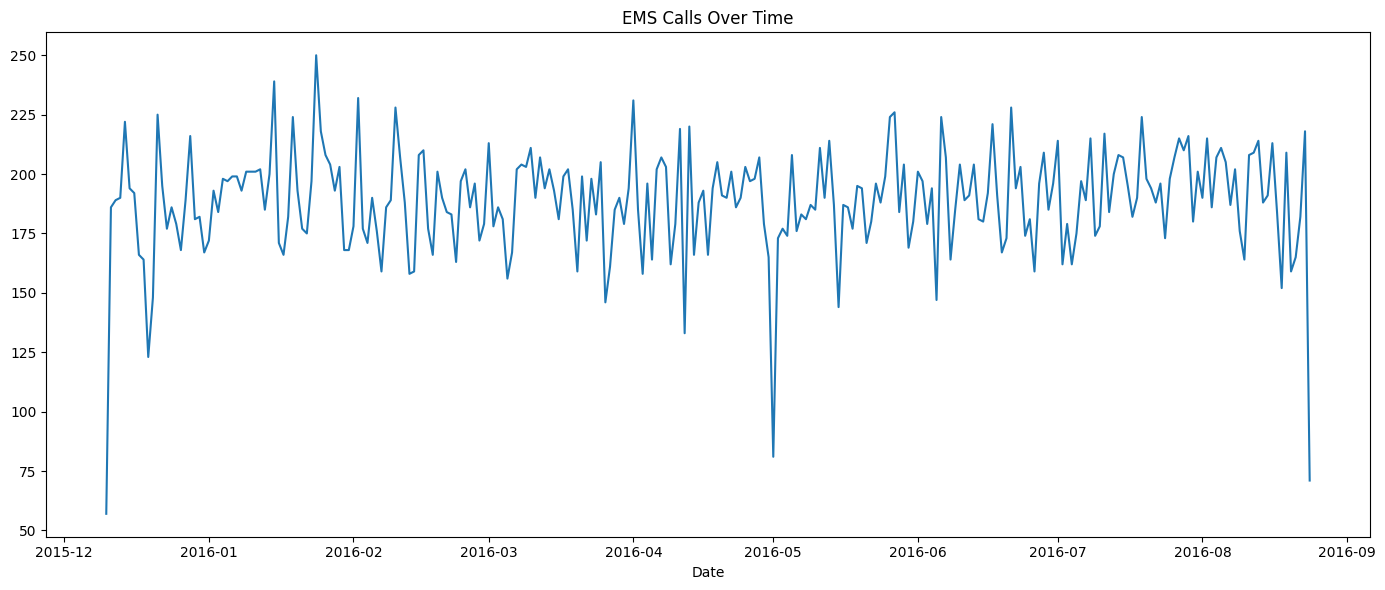

In [61]:
# Plot EMS emergency calls over time
plt.figure(figsize=(14,6))

df[df['Reason']=='EMS'] \
    .groupby('Date') \
    .count()['twp'] \
    .plot()

plt.title('EMS Calls Over Time')

plt.tight_layout()


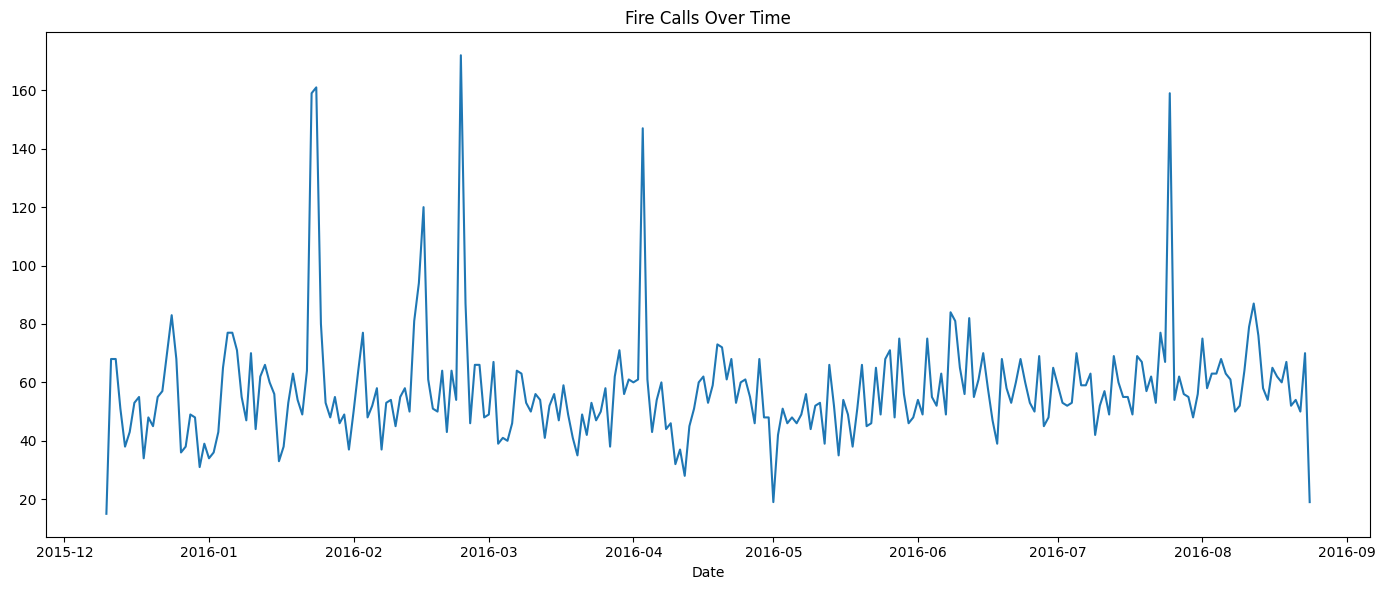

In [62]:
# Plot Fire emergency calls over time
plt.figure(figsize=(14,6))

df[df['Reason']=='Fire'] \
    .groupby('Date') \
    .count()['twp'] \
    .plot()

plt.title('Fire Calls Over Time')

plt.tight_layout()

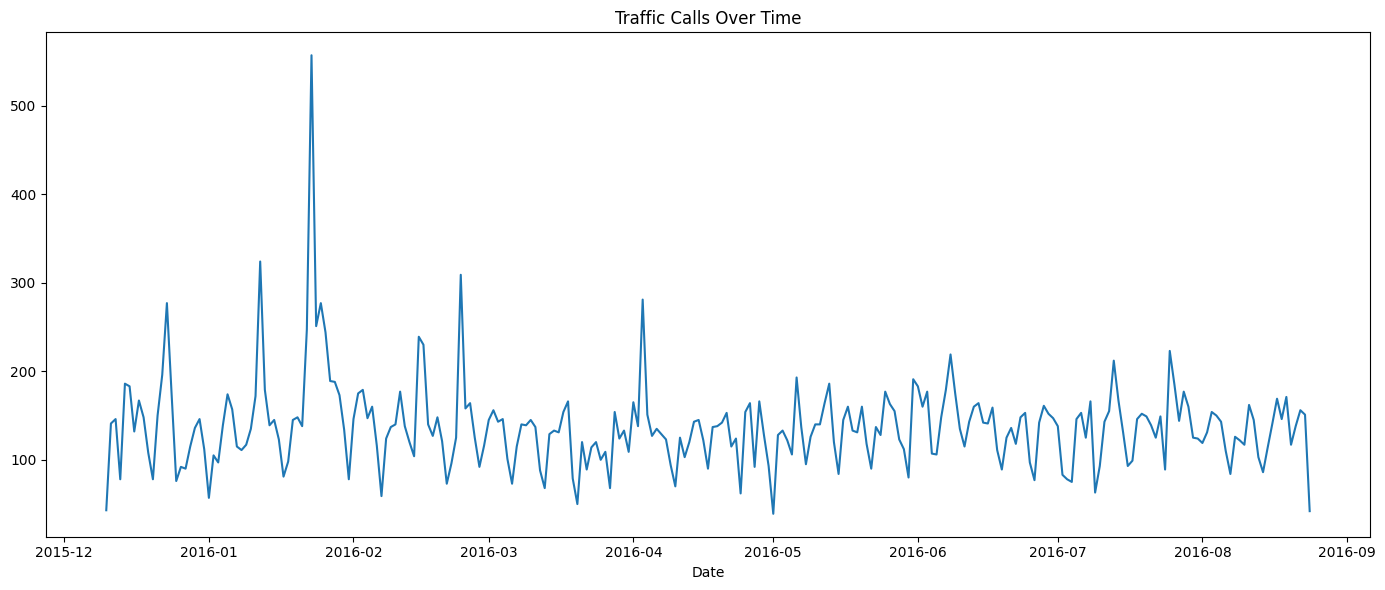

In [63]:
# Plot Traffic emergency calls over time
plt.figure(figsize=(14,6))

df[df['Reason']=='Traffic'] \
    .groupby('Date') \
    .count()['twp'] \
    .plot()

plt.title('Traffic Calls Over Time')

plt.tight_layout()

# Heatmap Analysis

In [64]:
#creating pivot table
dayHour = df.groupby(
    by=['Day of Week','Hour']
).count()['Reason'].unstack()

In [65]:
# Display pivot table structure
dayHour.head()

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day of Week,,,,,,,,,,,,,,,,,,,,,
Fri,275,235,191,175,201,194,372,598,742,752,...,932,980,1039,980,820,696,667,559,514,474
Mon,282,221,201,194,204,267,397,653,819,786,...,869,913,989,997,885,746,613,497,472,325
Sat,375,301,263,260,224,231,257,391,459,640,...,789,796,848,757,778,696,628,572,506,467
Sun,383,306,286,268,242,240,300,402,483,620,...,684,691,663,714,670,655,537,461,415,330
Thu,278,202,233,159,182,203,362,570,777,828,...,876,969,935,1013,810,698,617,553,424,354


<Axes: xlabel='Hour', ylabel='Day of Week'>

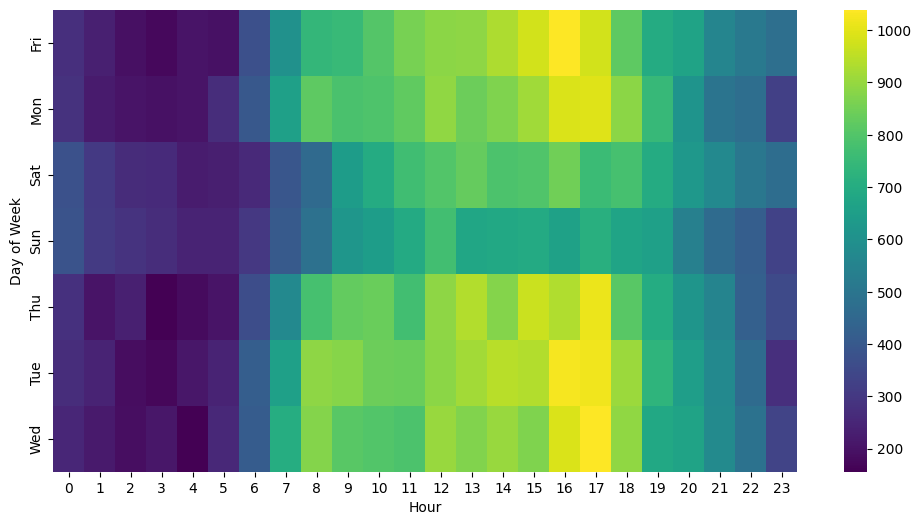

In [66]:
# Create heatmap to visualize call density
# across days and hours
plt.figure(figsize=(12,6))

sns.heatmap(dayHour, cmap='viridis')